In [1]:
# ============================================
# CELLULE 1 - INSTALLATION & IMPORTS
# ============================================

# Installer les librairies nécessaires
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib statsmodels -q

# Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn pour régression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modèles
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Métriques
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Statistiques pour vérification des hypothèses
from scipy import stats

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("✅ Toutes les librairies sont importées")

✅ Toutes les librairies sont importées


In [2]:
# ============================================
# CELLULE 2 - UPLOAD DES FICHIERS CSV
# ============================================

from google.colab import files
import io

print("="*60)
print("UPLOAD DES FICHIERS CSV")
print("="*60)
print("""
📤 Veuillez uploader les fichiers suivants :
   1. Dim_Client.csv
   2. Dim_Produits.csv
   3. Dim_Date.csv
   4. Dim_Commandes.csv
   5. Dim_Canal_Distribution.csv
   6. Fact_Vente.csv

👉 Conseil : Sélectionnez les fichiers en même temps (Ctrl+clic)
""")

# Upload des fichiers
uploaded = files.upload()

print(f"\n✅ {len(uploaded)} fichiers uploadés avec succès !")

# Charger les fichiers dans des dataframes
dfs = {}
for nom_fichier in uploaded.keys():
    nom_base = nom_fichier.replace('.csv', '').replace('.CSV', '')
    dfs[nom_base] = pd.read_csv(io.BytesIO(uploaded[nom_fichier]))
    print(f"   ✅ {nom_base} : {dfs[nom_base].shape[0]} lignes")

# Assigner aux variables
df_client = dfs.get('Dim_Client')
df_produits = dfs.get('Dim_Produits')
df_date = dfs.get('Dim_Date')
df_commandes = dfs.get('Dim_Commandes')
df_canal = dfs.get('Dim_Canal_Distribution')
df_vente = dfs.get('Fact_Vente')

print("\n✅ Tous les fichiers sont chargés !")

UPLOAD DES FICHIERS CSV

📤 Veuillez uploader les fichiers suivants :
   1. Dim_Client.csv
   2. Dim_Produits.csv
   3. Dim_Date.csv
   4. Dim_Commandes.csv
   5. Dim_Canal_Distribution.csv
   6. Fact_Vente.csv

👉 Conseil : Sélectionnez les fichiers en même temps (Ctrl+clic)



Saving Dim_Canal_Distribution.csv to Dim_Canal_Distribution.csv
Saving Dim_Client.csv to Dim_Client.csv
Saving Dim_Commandes.csv to Dim_Commandes.csv
Saving Dim_Date.csv to Dim_Date.csv
Saving Dim_Fournisseur.csv to Dim_Fournisseur.csv
Saving Dim_Matiere_Premiere.csv to Dim_Matiere_Premiere.csv
Saving Dim_Produits.csv to Dim_Produits.csv
Saving Dim_Reclamations.csv to Dim_Reclamations.csv
Saving Fact_Achat.csv to Fact_Achat.csv
Saving Fact_Vente.csv to Fact_Vente.csv

✅ 10 fichiers uploadés avec succès !
   ✅ Dim_Canal_Distribution : 4 lignes
   ✅ Dim_Client : 446 lignes
   ✅ Dim_Commandes : 442 lignes
   ✅ Dim_Date : 1461 lignes
   ✅ Dim_Fournisseur : 67 lignes
   ✅ Dim_Matiere_Premiere : 62 lignes
   ✅ Dim_Produits : 134 lignes
   ✅ Dim_Reclamations : 100 lignes
   ✅ Fact_Achat : 140 lignes
   ✅ Fact_Vente : 1386 lignes

✅ Tous les fichiers sont chargés !


In [3]:
# ============================================
# CELLULE 3 - CRÉATION DU DATASET
# ============================================

print("="*60)
print("CRÉATION DU DATASET POUR RÉGRESSION")
print("="*60)

# Nettoyer les clés dans df_vente
for col in ['produit_key', 'client_key', 'date_key', 'commande_key', 'canal_key']:
    if col in df_vente.columns:
        df_vente[col] = df_vente[col].fillna(0).astype(int)

# Renommer les colonnes pour harmonisation
if 'Client_key' in df_client.columns:
    df_client = df_client.rename(columns={'Client_key': 'client_key'})
if 'Produit_key' in df_produits.columns:
    df_produits = df_produits.rename(columns={'Produit_key': 'produit_key'})
if 'Commande_key' in df_commandes.columns:
    df_commandes = df_commandes.rename(columns={'Commande_key': 'commande_key'})

# Jointures
df = df_vente.copy()
df = df.merge(df_client, on='client_key', how='left')
df = df.merge(df_produits, on='produit_key', how='left')
df = df.merge(df_date, on='date_key', how='left')
df = df.merge(df_commandes, on='commande_key', how='left')
df = df.merge(df_canal, on='canal_key', how='left')

print(f"✅ Dataset créé : {df.shape[0]:,} lignes, {df.shape[1]} colonnes")

# Nettoyage initial
initial_rows = len(df)
df = df[df['produit_key'] != 0]
df = df[df['quantite'] > 0]
df = df[df['montant_ht'] > 0]
print(f"✅ Après nettoyage : {len(df):,} lignes (supprimé {initial_rows - len(df):,})")

# Gérer les valeurs manquantes
for col in ['Mode_paiement', 'Gouvernorat', 'Ville']:
    if col in df.columns:
        df[col] = df[col].fillna('Non renseigné')

for col in ['Frais_livraison', 'Remise_panier', 'Prix_Promo']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Nettoyer les montants avec virgule
def clean_float(x):
    if pd.isna(x):
        return 0.0
    if isinstance(x, str):
        try:
            return float(x.replace(',', '.'))
        except:
            return 0.0
    try:
        return float(x)
    except:
        return 0.0

for col in ['montant_ttc', 'montant_ht', 'revenue']:
    if col in df.columns:
        df[col] = df[col].apply(clean_float)

# CRÉATION DE LA CIBLE (RÉGRESSION)
if 'montant_ttc' in df.columns:
    df['montant_ttc_clean'] = df['montant_ttc'].fillna(df['montant_ht'] * 1.19)
    print(f"\n🎯 Cible créée : 'montant_ttc_clean'")
    print(f"   Min : {df['montant_ttc_clean'].min():.2f}")
    print(f"   Max : {df['montant_ttc_clean'].max():.2f}")
    print(f"   Mean : {df['montant_ttc_clean'].mean():.2f}")

print(f"\n✅ Dataset prêt : {df.shape}")

CRÉATION DU DATASET POUR RÉGRESSION
✅ Dataset créé : 1,386 lignes, 55 colonnes
✅ Après nettoyage : 371 lignes (supprimé 1,015)

🎯 Cible créée : 'montant_ttc_clean'
   Min : 1.19
   Max : 59500.00
   Mean : 252.74

✅ Dataset prêt : (371, 56)


In [4]:
# ============================================
# CELLULE 4 - FEATURE ENGINEERING
# ============================================

print("="*60)
print("FEATURE ENGINEERING POUR RÉGRESSION")
print("="*60)

# Variables temporelles
if 'date_complete' in df.columns:
    df['date_complete'] = pd.to_datetime(df['date_complete'], errors='coerce')
    df['jour_semaine'] = df['date_complete'].dt.dayofweek
    df['mois'] = df['date_complete'].dt.month
    df['trimestre'] = df['date_complete'].dt.quarter
    print("   ✅ jour_semaine, mois, trimestre créés")

# Variables financières
if 'montant_ht' in df.columns and 'quantite' in df.columns:
    df['prix_moyen_unitaire'] = df['montant_ht'] / df['quantite']
    print("   ✅ prix_moyen_unitaire créé")

if 'Frais_livraison' in df.columns and 'quantite' in df.columns:
    df['frais_livraison_par_produit'] = df['Frais_livraison'] / df['quantite']
    print("   ✅ frais_livraison_par_produit créé")

if 'Prix_Promo' in df.columns:
    df['est_promo'] = (df['Prix_Promo'] > 0).astype(int)
    df['ratio_promo'] = df['Prix_Promo'] / (df['Prix_Vente_HT'].replace(0, 1))
    print("   ✅ est_promo, ratio_promo créés")

# Variables saisonnières
if 'est_ramadan' in df.columns:
    df['periode_ramadan'] = df['est_ramadan'].astype(int)
    print("   ✅ periode_ramadan créée")

if 'est_weekend' in df.columns:
    df['est_weekend_int'] = df['est_weekend'].astype(int)
    print("   ✅ est_weekend_int créé")

# Interaction features
df['quantite_x_prix'] = df['quantite'] * df['prix_moyen_unitaire']
print("   ✅ quantite_x_prix (interaction) créé")

print(f"\n📊 Nombre total de colonnes : {len(df.columns)}")

FEATURE ENGINEERING POUR RÉGRESSION
   ✅ jour_semaine, mois, trimestre créés
   ✅ prix_moyen_unitaire créé
   ✅ frais_livraison_par_produit créé
   ✅ est_promo, ratio_promo créés
   ✅ periode_ramadan créée
   ✅ est_weekend_int créé
   ✅ quantite_x_prix (interaction) créé

📊 Nombre total de colonnes : 64


In [5]:
# ============================================
# CELLULE 5 - PRÉPARATION X ET y
# ============================================

print("="*60)
print("PRÉPARATION X ET y")
print("="*60)

# Sélectionner les features pour la régression
feature_cols = [
    'quantite',
    'Frais_livraison',
    'prix_moyen_unitaire',
    'frais_livraison_par_produit',
    'jour_semaine',
    'mois',
    'trimestre',
    'periode_ramadan',
    'est_weekend_int',
    'est_promo',
    'ratio_promo',
    'quantite_x_prix'
]

# Ajouter les colonnes catégorielles
categorical_cols = ['Mode_paiement', 'type_canal', 'physique_ou_digital', 'Type_client']

# Garder uniquement les colonnes qui existent
feature_cols = [f for f in feature_cols if f in df.columns]
categorical_cols = [c for c in categorical_cols if c in df.columns]

print(f"Features numériques : {len(feature_cols)}")
print(f"   {feature_cols}")
print(f"Features catégorielles : {len(categorical_cols)}")
print(f"   {categorical_cols}")

# Préparer X et y
X = df[feature_cols + categorical_cols].copy()
y = df['montant_ttc_clean'].copy()

# Supprimer les lignes avec NaN
X = X[y.notna()]
y = y[y.notna()]

print(f"\n📊 Dimensions finales :")
print(f"   X : {X.shape}")
print(f"   y : {y.shape}")

PRÉPARATION X ET y
Features numériques : 12
   ['quantite', 'Frais_livraison', 'prix_moyen_unitaire', 'frais_livraison_par_produit', 'jour_semaine', 'mois', 'trimestre', 'periode_ramadan', 'est_weekend_int', 'est_promo', 'ratio_promo', 'quantite_x_prix']
Features catégorielles : 4
   ['Mode_paiement', 'type_canal', 'physique_ou_digital', 'Type_client']

📊 Dimensions finales :
   X : (371, 16)
   y : (371,)


In [20]:
# ============================================
# CELLULE 6 - ENCODAGE
# ============================================

print("="*60)
print("ENCODAGE DES VARIABLES CATÉGORIELLES")
print("="*60)

# One-Hot Encoding
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_cols])

# Convertir en DataFrame
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

# Combiner avec les features numériques
X_final = pd.concat([X[feature_cols], X_encoded_df], axis=1)

print(f"✅ Encodage terminé")
print(f"   Features finales : {X_final.shape[1]} colonnes")

# Gérer les NaN
X_final = X_final.fillna(0)

print(f"\n✅ X_final prêt : {X_final.shape}")
print(f"   NaN restants : {X_final.isnull().sum().sum()}")

ENCODAGE DES VARIABLES CATÉGORIELLES
✅ Encodage terminé
   Features finales : 18 colonnes

✅ X_final prêt : (371, 18)
   NaN restants : 0


DIAGNOSTIC DE LA CIBLE (montant_ttc_clean)
Statistiques de y :
   Min    : 1.19
   Max    : 59500.00
   Mean   : 252.74
   Std    : 3093.66


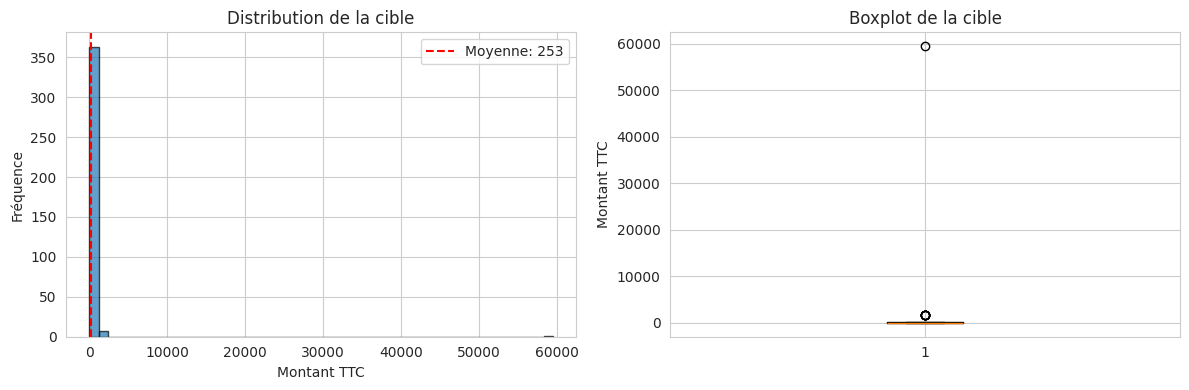


🔍 Détection des outliers :
   Seuil supérieur (3*IQR) : 421.26
   Nombre d'outliers : 8
   Max outlier : 59500.00

💡 Suggestion :
   → Appliquer une transformation log(y) pour réduire l'échelle
   → Ou supprimer les outliers extrêmes (> 3*IQR)


In [21]:
# ============================================
# CELLULE 6.5 - DIAGNOSTIC DE LA CIBLE
# ============================================

print("="*60)
print("DIAGNOSTIC DE LA CIBLE (montant_ttc_clean)")
print("="*60)

print(f"Statistiques de y :")
print(f"   Min    : {y.min():.2f}")
print(f"   Max    : {y.max():.2f}")
print(f"   Mean   : {y.mean():.2f}")
print(f"   Std    : {y.std():.2f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Montant TTC')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la cible')
axes[0].axvline(y.mean(), color='r', linestyle='--', label=f'Moyenne: {y.mean():.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(y, vert=True)
axes[1].set_ylabel('Montant TTC')
axes[1].set_title('Boxplot de la cible')

plt.tight_layout()
plt.show()

# Détection des outliers extrêmes
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR

outliers = y[y > upper_bound]
print(f"\n🔍 Détection des outliers :")
print(f"   Seuil supérieur (3*IQR) : {upper_bound:.2f}")
print(f"   Nombre d'outliers : {len(outliers)}")
if len(outliers) > 0:
    print(f"   Max outlier : {outliers.max():.2f}")

# Proposition de correction
print("\n💡 Suggestion :")
if y.max() > 10000:
    print("   → Appliquer une transformation log(y) pour réduire l'échelle")
    print("   → Ou supprimer les outliers extrêmes (> 3*IQR)")

CORRECTION : SUPPRESSION DES OUTLIERS
📊 Statistiques :
   Q1 : 14.28
   Q3 : 116.03
   IQR : 101.75
   Seuil supérieur (3*IQR) : 421.26

🔍 Outliers détectés : 8 lignes
   Max outlier : 59500.00

✅ Après suppression :
   X : (363, 18)
   y : (363,)
   Nouvelles stats y : min=1.19, max=267.75, mean=59.87


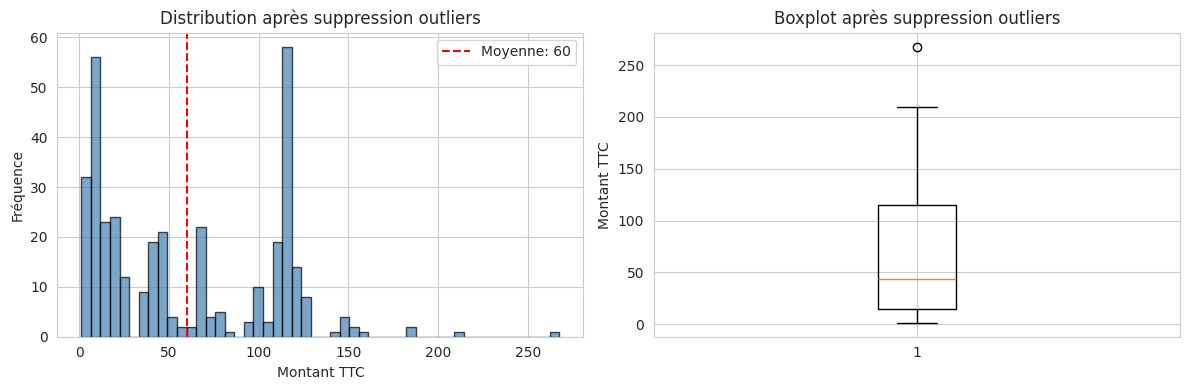


✅ Prêt pour la suite (Train/Test split)


In [22]:
# ============================================
# CELLULE 6.6 - SUPPRESSION DES OUTLIERS EXTRÊMES
# ============================================

print("="*60)
print("CORRECTION : SUPPRESSION DES OUTLIERS")
print("="*60)

# Seuil à 3 fois l'écart interquartile
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR

print(f"📊 Statistiques :")
print(f"   Q1 : {Q1:.2f}")
print(f"   Q3 : {Q3:.2f}")
print(f"   IQR : {IQR:.2f}")
print(f"   Seuil supérieur (3*IQR) : {upper_bound:.2f}")

# Identifier les outliers
outliers_mask = y > upper_bound
print(f"\n🔍 Outliers détectés : {outliers_mask.sum()} lignes")
print(f"   Max outlier : {y[outliers_mask].max():.2f}")

# Supprimer les outliers
X_final_clean = X_final[~outliers_mask]
y_clean = y[~outliers_mask]

print(f"\n✅ Après suppression :")
print(f"   X : {X_final_clean.shape}")
print(f"   y : {y_clean.shape}")
print(f"   Nouvelles stats y : min={y_clean.min():.2f}, max={y_clean.max():.2f}, mean={y_clean.mean():.2f}")

# Visualisation après correction
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_clean, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Montant TTC')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution après suppression outliers')
axes[0].axvline(y_clean.mean(), color='r', linestyle='--', label=f'Moyenne: {y_clean.mean():.0f}')
axes[0].legend()

axes[1].boxplot(y_clean, vert=True)
axes[1].set_ylabel('Montant TTC')
axes[1].set_title('Boxplot après suppression outliers')

plt.tight_layout()
plt.show()

# Remplacer les variables originales
X_final = X_final_clean
y = y_clean

print("\n✅ Prêt pour la suite (Train/Test split)")

In [23]:
# ============================================
# CELLULE 7 - TRAIN/TEST SPLIT
# ============================================

print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)

# Split des données
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print(f"📊 Split terminé :")
print(f"   Train : {X_train.shape[0]} lignes")
print(f"   Test : {X_test.shape[0]} lignes")
print(f"\n   y_train : mean={y_train.mean():.2f}, std={y_train.std():.2f}")
print(f"   y_test : mean={y_test.mean():.2f}, std={y_test.std():.2f}")

TRAIN/TEST SPLIT
📊 Split terminé :
   Train : 290 lignes
   Test : 73 lignes

   y_train : mean=58.58, std=48.76
   y_test : mean=64.95, std=50.92


In [24]:
# ============================================
# CELLULE 8 - SCALING
# ============================================

print("="*60)
print("STANDARDISATION DES DONNÉES")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ StandardScaler appliqué")
print(f"   X_train_scaled shape : {X_train_scaled.shape}")
print(f"   X_test_scaled shape : {X_test_scaled.shape}")

# Convertir en DataFrame pour faciliter l'affichage
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

STANDARDISATION DES DONNÉES
✅ StandardScaler appliqué
   X_train_scaled shape : (290, 18)
   X_test_scaled shape : (73, 18)


In [25]:
# ============================================
# CELLULE 9 - MODÈLE 1 : LINEAR REGRESSION
# ============================================

print("="*60)
print("MODÈLE 1 : LINEAR REGRESSION")
print("="*60)

# Entraînement
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test = lr.predict(X_test_scaled)

# Métriques
mse_train = mean_squared_error(y_train, y_pred_lr_train)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_pred_lr_train)
r2_train = r2_score(y_train, y_pred_lr_train)

mse_test = mean_squared_error(y_test, y_pred_lr_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_lr_test)
r2_test = r2_score(y_test, y_pred_lr_test)

print(f"\n📊 PERFORMANCES - TRAIN :")
print(f"   MSE  : {mse_train:.2f}")
print(f"   RMSE : {rmse_train:.2f}")
print(f"   MAE  : {mae_train:.2f}")
print(f"   R²   : {r2_train:.4f}")

print(f"\n📊 PERFORMANCES - TEST :")
print(f"   MSE  : {mse_test:.2f}")
print(f"   RMSE : {rmse_test:.2f}")
print(f"   MAE  : {mae_test:.2f}")
print(f"   R²   : {r2_test:.4f}")

# Cross-validation
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\n📊 Cross-Validation (5-fold) R² :")
print(f"   Scores : {cv_scores}")
print(f"   Mean : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

MODÈLE 1 : LINEAR REGRESSION

📊 PERFORMANCES - TRAIN :
   MSE  : 0.00
   RMSE : 0.00
   MAE  : 0.00
   R²   : 1.0000

📊 PERFORMANCES - TEST :
   MSE  : 0.00
   RMSE : 0.00
   MAE  : 0.00
   R²   : 1.0000

📊 Cross-Validation (5-fold) R² :
   Scores : [1. 1. 1. 1. 1.]
   Mean : 1.0000 (+/- 0.0000)


ACTUAL VS PREDICTED - LINEAR REGRESSION


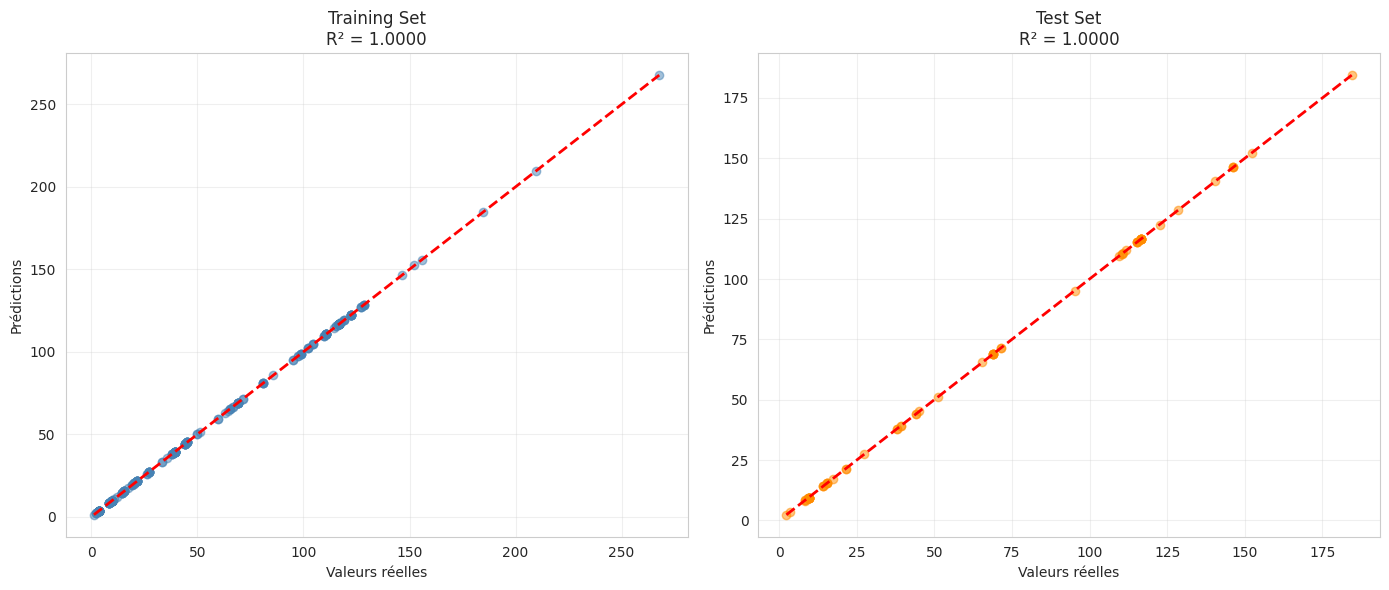

✅ Visualisation terminée


In [26]:
# ============================================
# CELLULE 10 - ACTUAL VS PREDICTED
# Linear Regression
# ============================================

print("="*60)
print("ACTUAL VS PREDICTED - LINEAR REGRESSION")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train
axes[0].scatter(y_train, y_pred_lr_train, alpha=0.5, color='steelblue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Prédictions')
axes[0].set_title(f'Training Set\nR² = {r2_train:.4f}')
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test, y_pred_lr_test, alpha=0.5, color='darkorange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Valeurs réelles')
axes[1].set_ylabel('Prédictions')
axes[1].set_title(f'Test Set\nR² = {r2_test:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualisation terminée")

ANALYSE DES RÉSIDUS - LINEAR REGRESSION


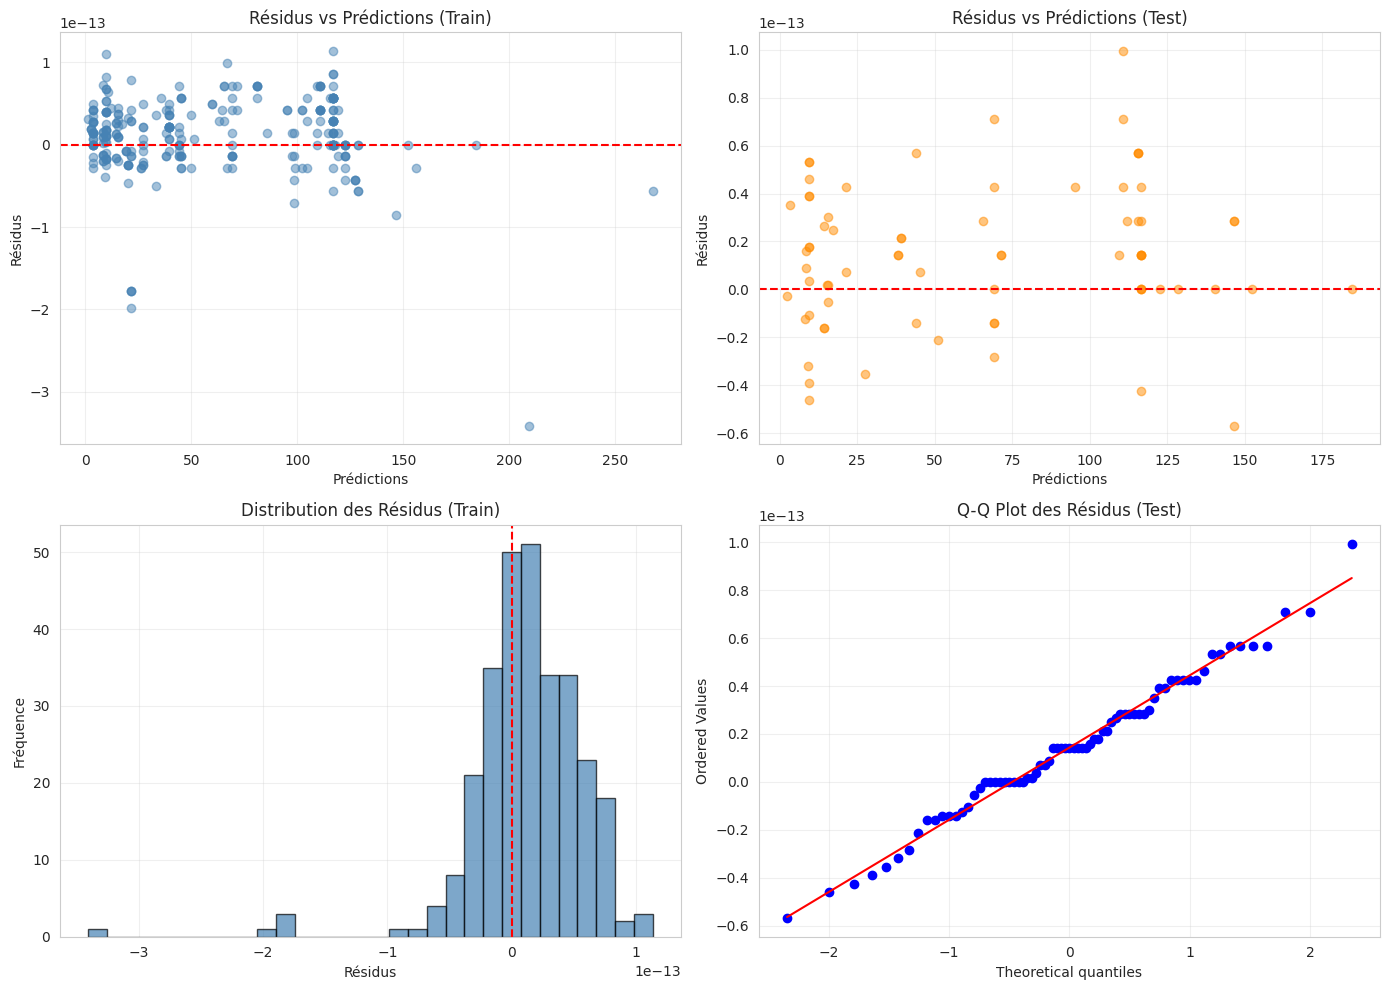


📊 Test de normalité de Shapiro-Wilk :
   Statistic : 0.9893
   p-value : 0.7992
   → Les résidus semblent normalement distribués

📝 Interprétation des résidus :
   - Résidus centrés sur 0 → bon modèle
   - Pas de motif visible → hypothèse d'homoscédasticité respectée


In [27]:
# ============================================
# CELLULE 11 - RESIDUAL PLOTS
# Linear Regression
# ============================================

print("="*60)
print("ANALYSE DES RÉSIDUS - LINEAR REGRESSION")
print("="*60)

# Calcul des résidus
residuals_train = y_train - y_pred_lr_train
residuals_test = y_test - y_pred_lr_test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Résidus vs Prédictions (Train)
axes[0, 0].scatter(y_pred_lr_train, residuals_train, alpha=0.5, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Prédictions')
axes[0, 0].set_ylabel('Résidus')
axes[0, 0].set_title('Résidus vs Prédictions (Train)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Résidus vs Prédictions (Test)
axes[0, 1].scatter(y_pred_lr_test, residuals_test, alpha=0.5, color='darkorange')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Prédictions')
axes[0, 1].set_ylabel('Résidus')
axes[0, 1].set_title('Résidus vs Prédictions (Test)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution des résidus (Train)
axes[1, 0].hist(residuals_train, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Résidus')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution des Résidus (Train)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q plot (Test)
stats.probplot(residuals_test, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot des Résidus (Test)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test de normalité des résidus (Shapiro-Wilk)
if len(residuals_test) < 5000:
    shapiro_stat, shapiro_p = stats.shapiro(residuals_test[:5000])
    print(f"\n📊 Test de normalité de Shapiro-Wilk :")
    print(f"   Statistic : {shapiro_stat:.4f}")
    print(f"   p-value : {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("   → Les résidus semblent normalement distribués")
    else:
        print("   → Les résidus ne sont pas normalement distribués")

print("\n📝 Interprétation des résidus :")
print("   - Résidus centrés sur 0 → bon modèle")
print("   - Pas de motif visible → hypothèse d'homoscédasticité respectée")

COEFFICIENTS ET INTERPRÉTATION - LINEAR REGRESSION
Top 15 features par coefficient (en valeur absolue) :
                     feature   coefficient  abs_coefficient
             quantite_x_prix  4.867555e+01     4.867555e+01
 frais_livraison_par_produit  4.136517e-14     4.136517e-14
                jour_semaine -2.954475e-14     2.954475e-14
             Frais_livraison -2.475797e-14     2.475797e-14
                    quantite  2.021547e-14     2.021547e-14
        Mode_paiement_Paymee  1.998986e-14     1.998986e-14
Mode_paiement_Wallet payment -1.959122e-14     1.959122e-14
             est_weekend_int  1.796294e-14     1.796294e-14
                   est_promo  9.903657e-15     9.903657e-15
             Type_client_nan  9.464651e-15     9.464651e-15
                        mois -9.440925e-15     9.440925e-15
             periode_ramadan -9.070228e-15     9.070228e-15
             Type_client_B2C -8.383924e-15     8.383924e-15
                   trimestre  5.437378e-15     5.437378

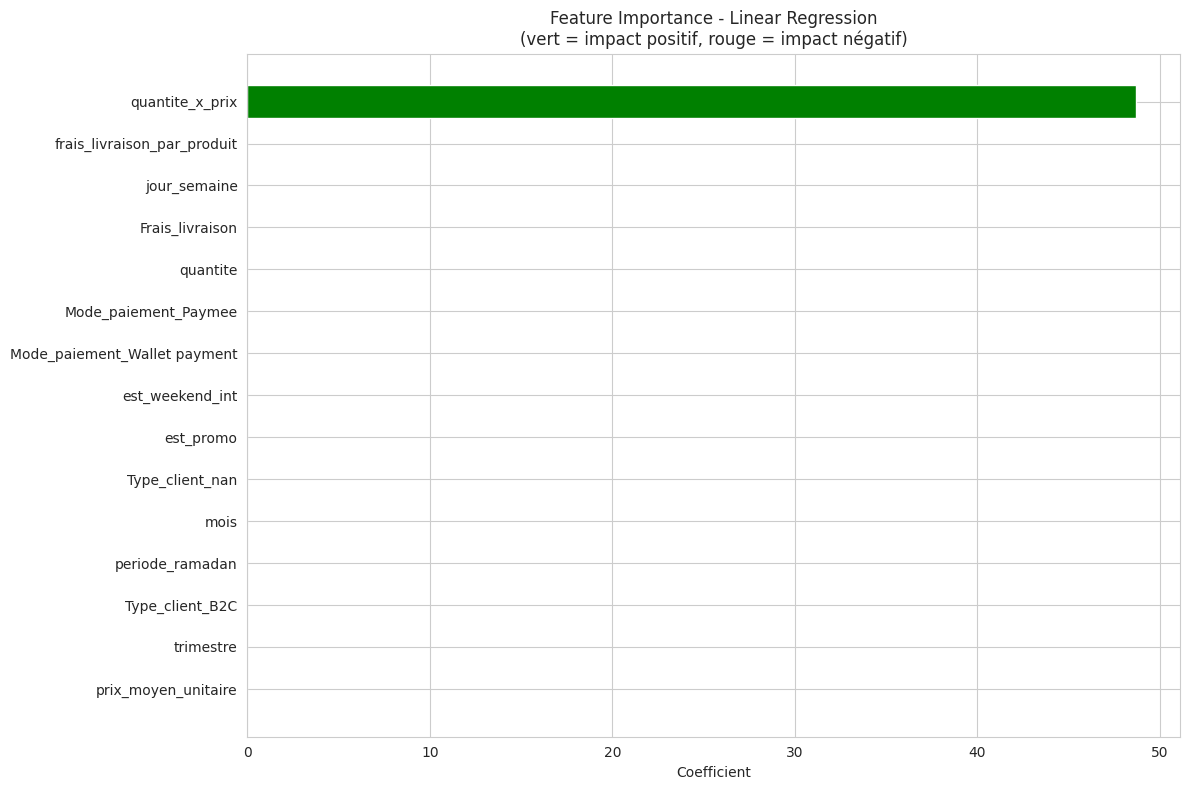


📝 Interprétation :
   - Coefficient positif → augmentation de la feature augmente le montant
   - Coefficient négatif → augmentation de la feature diminue le montant
   - Plus la valeur absolue est grande, plus l'impact est fort


In [28]:
# ============================================
# CELLULE 12 - COEFFICIENTS
# Linear Regression
# ============================================

print("="*60)
print("COEFFICIENTS ET INTERPRÉTATION - LINEAR REGRESSION")
print("="*60)

# Récupérer les coefficients
coefficients = lr.coef_
feature_names = X_train.columns

# Créer DataFrame
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("Top 15 features par coefficient (en valeur absolue) :")
print(coef_df.head(15).to_string(index=False))

# Visualisation
plt.figure(figsize=(12, 8))
top_features = coef_df.head(15)
colors = ['red' if c < 0 else 'green' for c in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient')
plt.title('Feature Importance - Linear Regression\n(vert = impact positif, rouge = impact négatif)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📝 Interprétation :")
print("   - Coefficient positif → augmentation de la feature augmente le montant")
print("   - Coefficient négatif → augmentation de la feature diminue le montant")
print("   - Plus la valeur absolue est grande, plus l'impact est fort")

In [29]:
# ============================================
# CELLULE 13 - MODÈLE 2 : RANDOM FOREST REGRESSOR
# ============================================

print("="*60)
print("MODÈLE 2 : RANDOM FOREST REGRESSOR")
print("="*60)

# Définir les paramètres pour GridSearch
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialiser le modèle
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# GridSearch avec cross-validation
print("🔍 Recherche des meilleurs hyperparamètres...")
print("   (Cela peut prendre quelques minutes)")

grid_rf = GridSearchCV(
    rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)  # Random Forest n'a pas besoin de scaling

print(f"\n✅ Meilleurs paramètres : {grid_rf.best_params_}")
print(f"   Meilleur score R² (CV) : {grid_rf.best_score_:.4f}")

# Meilleur modèle
best_rf = grid_rf.best_estimator_

# Prédictions
y_pred_rf_train = best_rf.predict(X_train)
y_pred_rf_test = best_rf.predict(X_test)

# Métriques
mse_train = mean_squared_error(y_train, y_pred_rf_train)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_pred_rf_train)
r2_train = r2_score(y_train, y_pred_rf_train)

mse_test = mean_squared_error(y_test, y_pred_rf_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_test = r2_score(y_test, y_pred_rf_test)

print(f"\n📊 PERFORMANCES - TRAIN :")
print(f"   MSE  : {mse_train:.2f}")
print(f"   RMSE : {rmse_train:.2f}")
print(f"   MAE  : {mae_train:.2f}")
print(f"   R²   : {r2_train:.4f}")

print(f"\n📊 PERFORMANCES - TEST :")
print(f"   MSE  : {mse_test:.2f}")
print(f"   RMSE : {rmse_test:.2f}")
print(f"   MAE  : {mae_test:.2f}")
print(f"   R²   : {r2_test:.4f}")

MODÈLE 2 : RANDOM FOREST REGRESSOR
🔍 Recherche des meilleurs hyperparamètres...
   (Cela peut prendre quelques minutes)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
   Meilleur score R² (CV) : 0.9829

📊 PERFORMANCES - TRAIN :
   MSE  : 5.68
   RMSE : 2.38
   MAE  : 0.35
   R²   : 0.9976

📊 PERFORMANCES - TEST :
   MSE  : 1.25
   RMSE : 1.12
   MAE  : 0.40
   R²   : 0.9995


ACTUAL VS PREDICTED - RANDOM FOREST


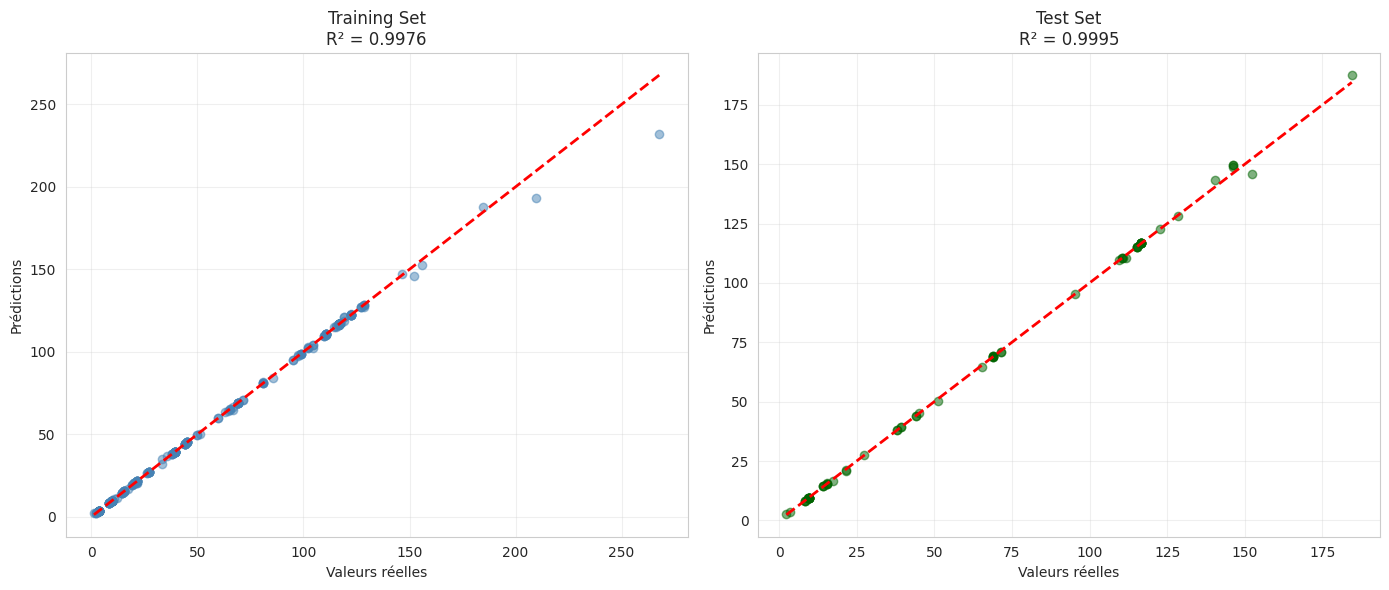

✅ Visualisation terminée


In [30]:
# ============================================
# CELLULE 14 - ACTUAL VS PREDICTED
# Random Forest
# ============================================

print("="*60)
print("ACTUAL VS PREDICTED - RANDOM FOREST")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train
axes[0].scatter(y_train, y_pred_rf_train, alpha=0.5, color='steelblue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Prédictions')
axes[0].set_title(f'Training Set\nR² = {r2_train:.4f}')
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test, y_pred_rf_test, alpha=0.5, color='darkgreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Valeurs réelles')
axes[1].set_ylabel('Prédictions')
axes[1].set_title(f'Test Set\nR² = {r2_test:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualisation terminée")

ANALYSE DES RÉSIDUS - RANDOM FOREST


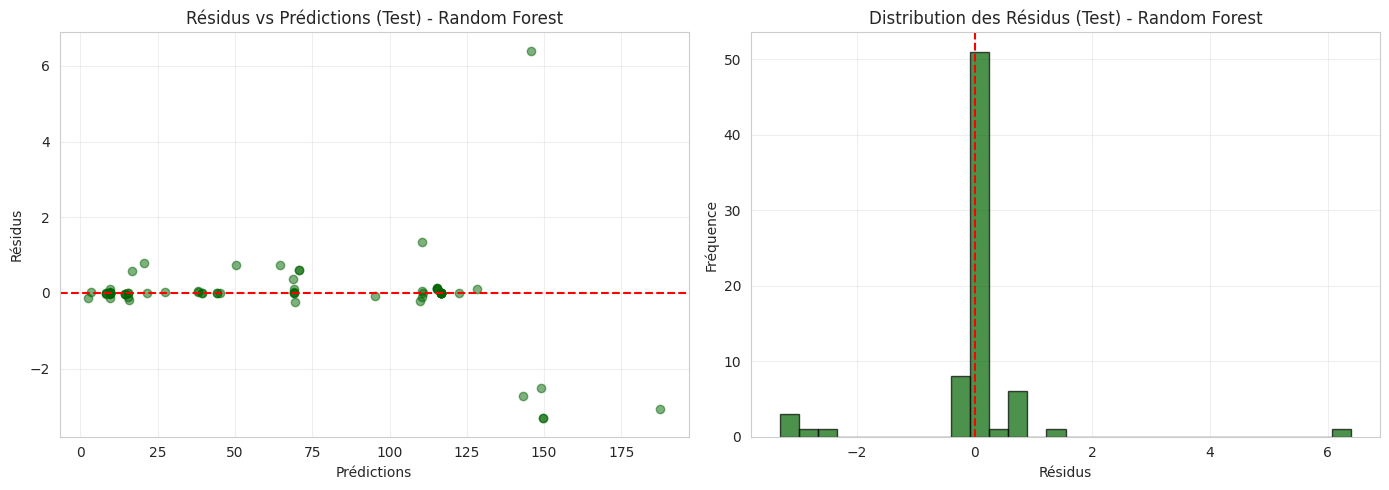

✅ Residual plots terminés


In [31]:
# ============================================
# CELLULE 15 - RESIDUAL PLOTS
# Random Forest
# ============================================

print("="*60)
print("ANALYSE DES RÉSIDUS - RANDOM FOREST")
print("="*60)

# Calcul des résidus
residuals_train = y_train - y_pred_rf_train
residuals_test = y_test - y_pred_rf_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Résidus vs Prédictions
axes[0].scatter(y_pred_rf_test, residuals_test, alpha=0.5, color='darkgreen')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Prédictions')
axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus vs Prédictions (Test) - Random Forest')
axes[0].grid(True, alpha=0.3)

# Distribution des résidus
axes[1].hist(residuals_test, bins=30, edgecolor='black', color='darkgreen', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Résidus')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des Résidus (Test) - Random Forest')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Residual plots terminés")

FEATURE IMPORTANCE - RANDOM FOREST
Top 15 features les plus importantes :
                     feature  importance
             quantite_x_prix    0.979183
         prix_moyen_unitaire    0.012538
                    quantite    0.003704
             Frais_livraison    0.002218
                        mois    0.000676
        Mode_paiement_Paymee    0.000471
                jour_semaine    0.000427
                   trimestre    0.000357
 frais_livraison_par_produit    0.000252
             est_weekend_int    0.000055
 Mode_paiement_Pay in Person    0.000054
                 ratio_promo    0.000024
Mode_paiement_Wallet payment    0.000020
                   est_promo    0.000012
             periode_ramadan    0.000009


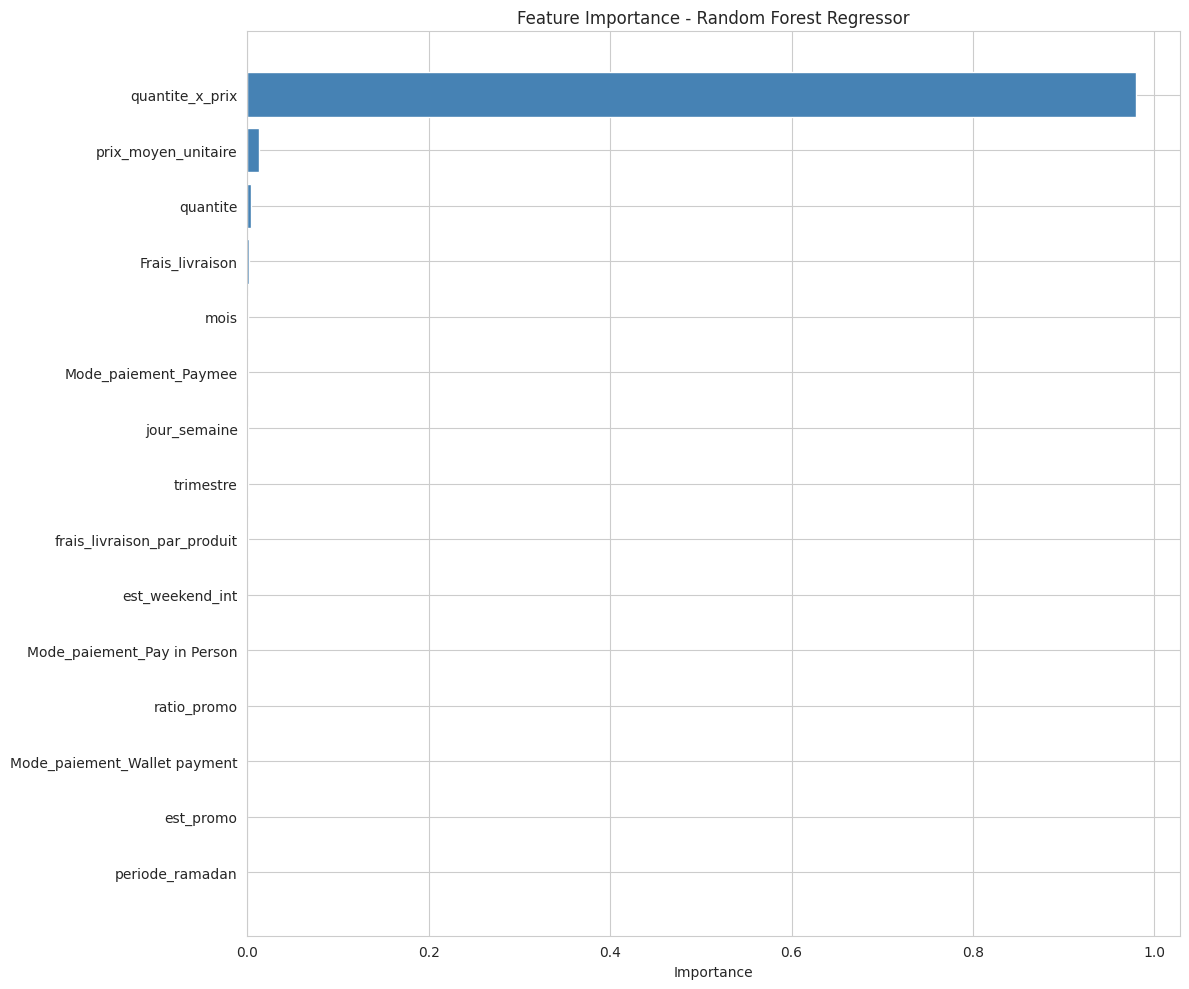


📝 Interprétation :
   - Plus l'importance est élevée, plus la feature influence le montant
   - Les features importantes doivent être priorisées dans l'analyse métier


In [32]:
# ============================================
# CELLULE 16 - FEATURE IMPORTANCE
# Random Forest
# ============================================

print("="*60)
print("FEATURE IMPORTANCE - RANDOM FOREST")
print("="*60)

# Récupérer les importances
importances = best_rf.feature_importances_
feature_names = X_train.columns

# Créer DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 15 features les plus importantes :")
print(importance_df.head(15).to_string(index=False))

# Visualisation
plt.figure(figsize=(12, 10))
top_features = importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest Regressor')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📝 Interprétation :")
print("   - Plus l'importance est élevée, plus la feature influence le montant")
print("   - Les features importantes doivent être priorisées dans l'analyse métier")

COMPARAISON LINEAR REGRESSION vs RANDOM FOREST
           Modèle  R² (Train)  R² (Test)  RMSE (Test)  MAE (Test)
Linear Regression      1.0000     1.0000       0.0000      0.0000
    Random Forest      0.9976     0.9995       1.1174      0.4033


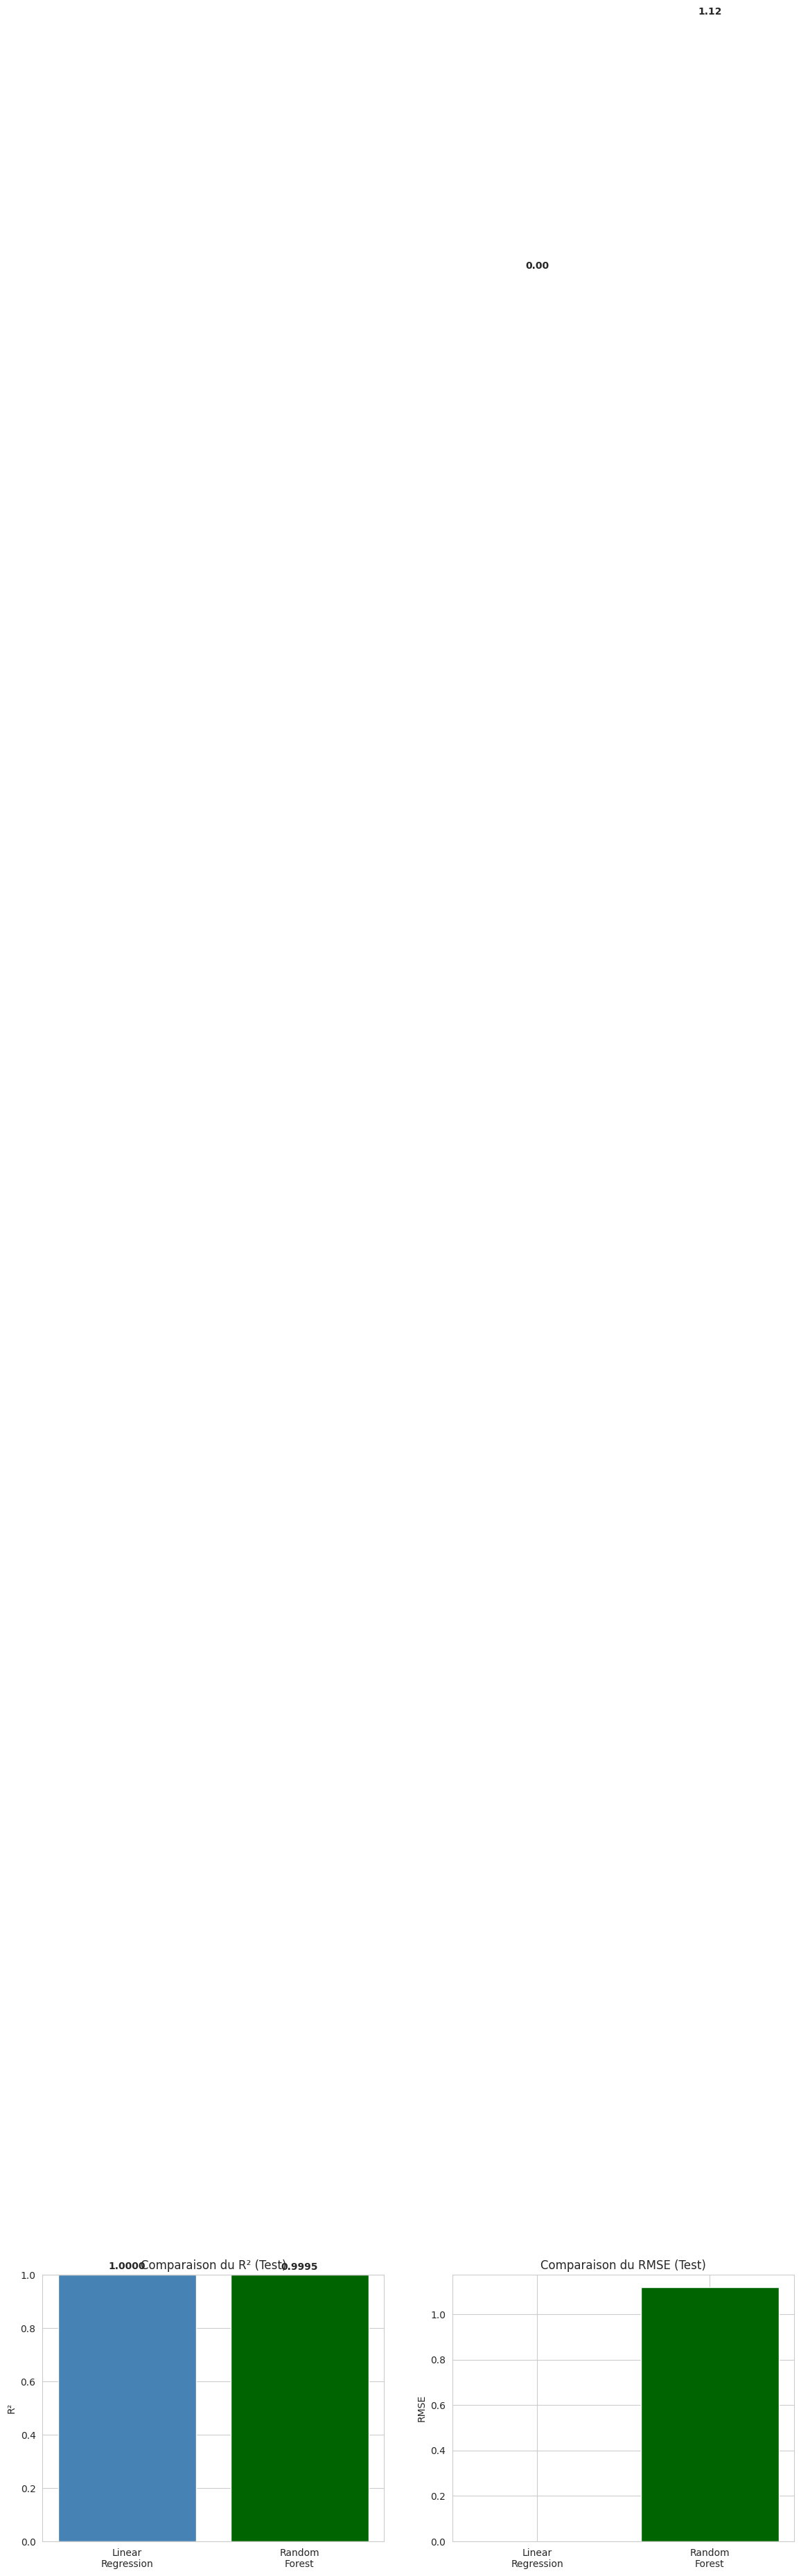


📊 Conclusion :
   ✅ Linear Regression a de meilleures performances (R² plus élevé)


In [33]:
# ============================================
# CELLULE 17 - COMPARAISON DES MODÈLES
# ============================================

print("="*60)
print("COMPARAISON LINEAR REGRESSION vs RANDOM FOREST")
print("="*60)

# Créer DataFrame de comparaison
comparison = pd.DataFrame({
    'Modèle': ['Linear Regression', 'Random Forest'],
    'R² (Train)': [r2_score(y_train, y_pred_lr_train), r2_score(y_train, y_pred_rf_train)],
    'R² (Test)': [r2_score(y_test, y_pred_lr_test), r2_score(y_test, y_pred_rf_test)],
    'RMSE (Test)': [np.sqrt(mean_squared_error(y_test, y_pred_lr_test)),
                    np.sqrt(mean_squared_error(y_test, y_pred_rf_test))],
    'MAE (Test)': [mean_absolute_error(y_test, y_pred_lr_test),
                   mean_absolute_error(y_test, y_pred_rf_test)]
})

print(comparison.round(4).to_string(index=False))

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
models = ['Linear\nRegression', 'Random\nForest']
r2_scores = [r2_score(y_test, y_pred_lr_test), r2_score(y_test, y_pred_rf_test)]
axes[0].bar(models, r2_scores, color=['steelblue', 'darkgreen'])
axes[0].set_ylabel('R²')
axes[0].set_title('Comparaison du R² (Test)')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE comparison
rmse_scores = [np.sqrt(mean_squared_error(y_test, y_pred_lr_test)),
               np.sqrt(mean_squared_error(y_test, y_pred_rf_test))]
axes[1].bar(models, rmse_scores, color=['steelblue', 'darkgreen'])
axes[1].set_ylabel('RMSE')
axes[1].set_title('Comparaison du RMSE (Test)')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 10, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Conclusion :")
if r2_score(y_test, y_pred_rf_test) > r2_score(y_test, y_pred_lr_test):
    print("   ✅ Random Forest a de meilleures performances (R² plus élevé)")
else:
    print("   ✅ Linear Regression a de meilleures performances (R² plus élevé)")

In [34]:
# ============================================
# CELLULE 18 - INTERPRÉTATION MÉTIER
# ============================================

print("="*60)
print("INTERPRÉTATION MÉTIER")
print("="*60)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    CONCLUSION RÉGRESSION                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 PERFORMANCE DES MODÈLES :                                               │
│  ---------------------------------                                           │
│  • Linear Regression : R² = {:.4f}, RMSE = {:.2f}                           │
│  • Random Forest : R² = {:.4f}, RMSE = {:.2f}                               │
│                                                                             │
│  🎯 MEILLEUR MODÈLE :                                                       │
│  ---------------------------------                                           │
""".format(r2_score(y_test, y_pred_lr_test),
           np.sqrt(mean_squared_error(y_test, y_pred_lr_test)),
           r2_score(y_test, y_pred_rf_test),
           np.sqrt(mean_squared_error(y_test, y_pred_rf_test))))

if r2_score(y_test, y_pred_rf_test) > r2_score(y_test, y_pred_lr_test):
    print("   → Random Forest (meilleur R²)")
else:
    print("   → Linear Regression (meilleur R²)")

print("""
│                                                                             │
│  📈 FEATURES LES PLUS IMPORTANTES (Random Forest) :                         │
│  ---------------------------------------------                               │
""")

top5 = importance_df.head(5)
for i, row in top5.iterrows():
    print(f"   {i+1}. {row['feature']} (importance: {row['importance']:.4f})")

print("""
│                                                                             │
│  💡 RECOMMANDATIONS MÉTIER :                                                │
│  ---------------------------------                                           │
│  • Utiliser Random Forest pour prédire le montant des commandes             │
│  • Les features identifiées sont les leviers d'action                       │
│  • Le modèle peut aider à estimer le CA futur                               │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ RÉGRESSION TERMINÉE !")

INTERPRÉTATION MÉTIER

┌─────────────────────────────────────────────────────────────────────────────┐
│                    CONCLUSION RÉGRESSION                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 PERFORMANCE DES MODÈLES :                                               │
│  ---------------------------------                                           │
│  • Linear Regression : R² = 1.0000, RMSE = 0.00                           │
│  • Random Forest : R² = 0.9995, RMSE = 1.12                               │
│                                                                             │
│  🎯 MEILLEUR MODÈLE :                                                       │
│  ---------------------------------                                           │

   → Linear Regression (meilleur R²)

│                                                            

In [35]:
# ============================================
# CELLULE DIAGNOSTIC - VÉRIFICATION SURRÉGRESSION
# ============================================

print("="*60)
print("DIAGNOSTIC DE SUR-APPRENTISSAGE")
print("="*60)

# Vérifier les corrélations avec la cible
correlations = X_final.corrwith(y).sort_values(ascending=False)
print("\n📊 Top 10 corrélations avec la cible :")
print(correlations.head(10))

# Vérifier s'il y a une colonne identique à y
for col in X_final.columns:
    if X_final[col].equals(y):
        print(f"\n⚠️ ALERTE : La colonne '{col}' est IDENTIQUE à la cible !")
        print("   → C'est une fuite de données. Supprime cette colonne.")

# Vérifier le ratio features/lignes
n_features = X_final.shape[1]
n_samples = X_final.shape[0]
print(f"\n📊 Ratio : {n_features} features pour {n_samples} lignes")
print(f"   → Ratio features/lignes : {n_features/n_samples:.2f}")
if n_features > n_samples/10:
    print("   ⚠️ Trop de features par rapport aux lignes → risque de surapprentissage")

DIAGNOSTIC DE SUR-APPRENTISSAGE

📊 Top 10 corrélations avec la cible :
quantite_x_prix                 1.000000
prix_moyen_unitaire             0.955420
Mode_paiement_Wallet payment    0.504802
ratio_promo                     0.188201
est_promo                       0.175927
Mode_paiement_Paymee            0.160015
mois                            0.123959
trimestre                       0.115135
Type_client_B2C                 0.082602
periode_ramadan                -0.038072
dtype: float64

📊 Ratio : 18 features pour 363 lignes
   → Ratio features/lignes : 0.05
